In [22]:
!pip install osmnx networkx folium matplotlib -q
!pip install folium -q
!pip install folium pandas numpy
!pip install osmnx folium matplotlib -q
!pip install osmnx folium networkx -q
!pip install folium pandas scikit-learn -q

In [23]:
#bài 23.1
import folium

# Tọa độ trung tâm UEH Cơ sở B
uehb = [10.761295603162457, 106.66833654397013]

locations = [
    ([10.7562, 106.6665], 'Bệnh viện Nhân dân 115'),
    ([10.7630, 106.6712], 'Co.opmart Nguyễn Tri Phương'),
    ([10.7680, 106.6735], 'Công viên Lê Thị Riêng'),
    ([10.7625, 106.6740], 'Trạm trung chuyển xe buýt Lê Hồng Phong'),
    ([10.7632, 106.6690], 'UBND Quận 10')
]

m = folium.Map(location=uehb, zoom_start=14)

# Marker chính (UEH)
folium.Marker(
    uehb,
    popup='Đại học Kinh tế TP.HCM - Cơ sở B',
    icon=folium.Icon(color='red', icon='info-sign')
).add_to(m)

# Nhóm các địa điểm lân cận
fg = folium.FeatureGroup(name="Các địa điểm lân cận")
for coords, name in locations:
    folium.Marker(
        location=coords,
        popup=name,
        tooltip='Xem thông tin',
        icon=folium.Icon(color='blue')
    ).add_to(fg)

fg.add_to(m)
folium.LayerControl().add_to(m)

m

In [24]:
#bài 2
from geopy.geocoders import Nominatim
from geopy.distance import geodesic
import folium
import time

nha_tho_duc_ba = (10.7798, 106.6990)
geolocator = Nominatim(user_agent="ueh_student_project")

diadiem = {
    "Sân bay Tân Sơn Nhất": "Tan Son Nhat Airport, Ho Chi Minh City",
    "Bến xe Miền Đông": "Mien Dong Bus Station, Binh Thanh, Ho Chi Minh City",
    "Gigamall Thủ Đức": "Gigamall, Thu Duc, Ho Chi Minh City",
    "Dinh Độc Lập": "Independence Palace, Ho Chi Minh City",
    "Chợ Bến Thành": "Ben Thanh Market, Ho Chi Minh City",
    "Aeon Mall Tân Phú": "Aeon Mall Tan Phu, Ho Chi Minh City",
    "Bitexco Tower": "Bitexco Financial Tower, Ho Chi Minh City",
    "Thảo Cầm Viên": "Saigon Zoo, Ho Chi Minh City",
    "Bảo tàng Chứng tích": "War Remnants Museum, Ho Chi Minh City",
    "Công viên Tao Đàn": "Tao Dan Park, Ho Chi Minh City"
}

m = folium.Map(location=nha_tho_duc_ba, zoom_start=13)

folium.Marker(
    nha_tho_duc_ba,
    popup="TRUNG TÂM: Nhà thờ Đức Bà",
    icon=folium.Icon(color='red', icon='star')
).add_to(m)
print("KHOẢNG CÁCH TỪ NHÀ THỜ ĐỨC BÀ ĐẾN")
for ten, dia_chi in diadiem.items():
    try:
        location = geolocator.geocode(dia_chi)
        if location:
            toa_do_moi = (location.latitude, location.longitude)
            kc = round(geodesic(nha_tho_duc_ba, toa_do_moi).km, 2)

            print(f"{ten:25}: {kc} km")

            folium.Marker(
                toa_do_moi,
                popup=f"{ten}: {kc} km",
                icon=folium.Icon(color='blue', icon='info-sign')
            ).add_to(m)

            # Vẽ đường nối giữa trung tâm và địa điểm
            folium.PolyLine(
                locations=[nha_tho_duc_ba, toa_do_moi],
                color='black', weight=1.5, opacity=0.6
            ).add_to(m)
        else:
            print(f"Lỗi tọa độ: {ten}")

        time.sleep(1.1)

    except Exception as e:
        print(f"Lỗi hệ thống tại {ten}: {e}")

m

KHOẢNG CÁCH TỪ NHÀ THỜ ĐỨC BÀ ĐẾN
Sân bay Tân Sơn Nhất     : 6.3 km
Bến xe Miền Đông         : 4.11 km
Gigamall Thủ Đức         : 5.84 km
Dinh Độc Lập             : 0.49 km
Chợ Bến Thành            : 0.81 km
Aeon Mall Tân Phú        : 9.45 km
Bitexco Tower            : 1.06 km
Thảo Cầm Viên            : 1.2 km
Bảo tàng Chứng tích      : 0.74 km
Công viên Tao Đàn        : 0.83 km


In [25]:
#bài 3
import pandas as pd
import folium
from folium.plugins import HeatMap

# 1. Đọc dữ liệu và lọc khách hàng
df = pd.read_csv('log_dataset.csv')
customers = df[df['Type'] == 'Customer'].copy()

# 2. Khởi tạo bản đồ tại trung tâm TP.HCM
m = folium.Map(location=[10.7769, 106.7009], zoom_start=11, tiles='CartoDB positron')

heat_data = customers[['Latitude', 'Longitude', 'Revenue']].values.tolist()

HeatMap(heat_data,
        radius=15,
        blur=10,
        min_opacity=0.4,
        gradient={0.2: 'blue', 0.4: 'lime', 0.6: 'orange', 1: 'red'}
       ).add_to(m)
m



- Vùng nóng (màu đỏ/cam): Mật độ khách hàng / đơn hàng cao nhất.
1. Tăng cường nguồn lực: bố trí thêm nhân viên bán hàng, giao hàng, chăm sóc khách hàng tại khu vực này.
2. Mở thêm điểm giao dịch / chi nhánh để phục vụ nhu cầu cao, giảm tải cho các điểm hiện có.
3. Ưu tiên khuyến mãi dành riêng cho khách hàng thân thiết tại vùng nóng để giữ chân họ.
4. Theo dõi sát sao biến động mật độ theo thời gian để điều chỉnh chiến lược kịp thời.
- Vùng vàng (mật độ trung bình)
1. Khảo sát thêm, đẩy mạnh marketing để nâng cấp thành vùng nóng.
- Vùng xanh (mật độ thấp)
1. Cần tìm hiểu nguyên nhân (ít dân cư, cạnh tranh, chưa tiếp cận) và có chính sách kích cầu (giảm giá, quảng cáo).

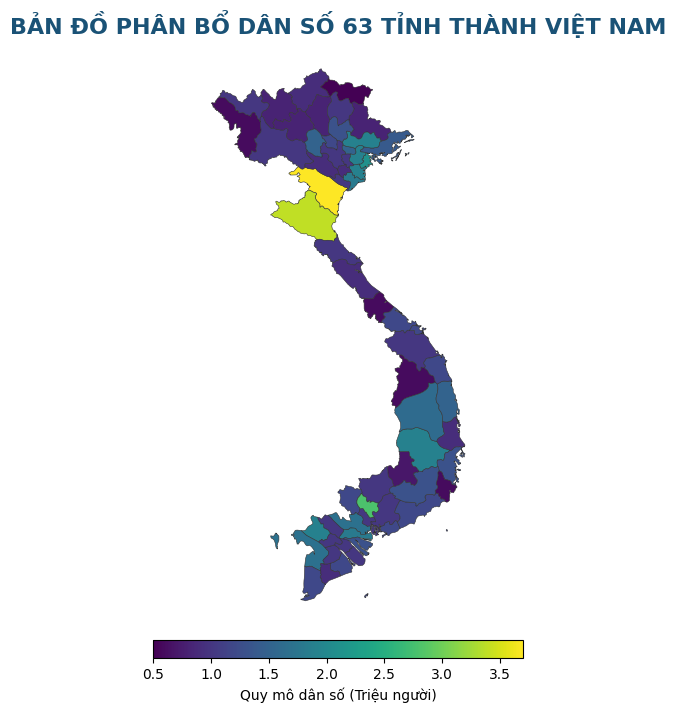

In [26]:
#bài 4
import geopandas as gpd
import matplotlib.pyplot as plt

df_vn = gpd.read_file('vietnam.json')

fig, ax = plt.subplots(1, 1, figsize=(6, 8))

# Vẽ bản đồ dựa trên cột Population_M
df_vn.plot(
    column='Population_M',
    cmap='viridis',
    legend=True,
    edgecolor='0.2',
    linewidth=0.4,
    ax=ax,
    legend_kwds={
        'label': "Quy mô dân số (Triệu người)",
        'orientation': "horizontal",
        'fraction': 0.03,
        'pad': 0.02
    }
)

ax.set_title('BẢN ĐỒ PHÂN BỔ DÂN SỐ 63 TỈNH THÀNH VIỆT NAM',
             fontsize=16, fontweight='bold', color='#1a5276')
ax.axis('off')

plt.show()

Nhận thấy dân số tập trung đông đúc tại các đô thị lớn (Hà Nội, TP.HCM, Hải Phòng, Cần Thơ, Bình Dương, Đồng Nai) --> đây là các thị trường tiêu thụ chính, cần ưu tiên đầu tư hạ tầng logistics và phân phối. Các tỉnh miền núi phía Bắc và Tây Nguyên có dân số thấp, doanh nghiệp nên áp dụng mô hình giao hàng tập trung (hub & spoke) để tối ưu chi phí. Dựa vào bản đồ, nhà quản trị có thể điều chỉnh kế hoạch mở rộng, phân bổ ngân sách marketing và quyết định vị trí đặt kho trung chuyển phù hợp với quy mô dân số từng vùng.

In [27]:
#bài 5
import folium
import pandas as pd

df = pd.read_csv('log_dataset.csv')
hub = df[df['Type'] == 'Hub'].iloc[0]
khach_hang = df[df['Type'] == 'Customer']

toa_do_kho = [hub['Latitude'], hub['Longitude']]

ban_do = folium.Map(location=toa_do_kho, zoom_start=12, tiles='CartoDB positron')

cac_vung = [
    {"ban_kinh": 3000, "mau": "green", "ten": "Vùng Nhanh (3km)"},
    {"ban_kinh": 5000, "mau": "orange", "ten": "Vùng Tiêu chuẩn (5km)"},
    {"ban_kinh": 10000, "mau": "red", "ten": "Vùng Mở rộng (10km)"}
]

for v in cac_vung:
    folium.Circle(
        location=toa_do_kho,
        radius=v["ban_kinh"],
        color=v["mau"],
        fill=True,
        fill_opacity=0.15,
        popup=v["ten"]
    ).add_to(ban_do)

# Đánh dấu kho hàng trung tâm
folium.Marker(
    location=toa_do_kho,
    popup=f"Kho: {hub['Note']}",
    icon=folium.Icon(color='blue', icon='warehouse', prefix='fa')
).add_to(ban_do)

# 295 khách hàng từ dữ liệu
for i, row in khach_hang.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=2,
        color='black',
        fill=True,
        opacity=0.4
    ).add_to(ban_do)

ban_do

1. Đánh giá khả năng tiếp cận:

Vùng 3km (Xanh): Tối ưu. Mật độ khách hàng cao, thời gian giao hàng tức thì, chi phí vận tải thấp nhất.

Vùng 5km (Cam): Ổn định. Vùng khai thác chủ lực, cân bằng tốt giữa tốc độ giao hàng và chi phí vận hành.

Vùng 10km (Đỏ): Kém hiệu quả. Khoảng cách xa làm tăng chi phí nhiên liệu và rủi ro trễ hẹn, biên lợi nhuận thấp.

2. Đề xuất phạm vi hoạt động tối ưu:

Phạm vi trọng điểm: Xác định bán kính 5km là vùng phục vụ chiến lược để tối ưu hóa nguồn lực và cam kết chất lượng dịch vụ.

Giải pháp mở rộng: Các khu vực ngoài 5km nên áp dụng chính sách gom đơn hoặc phụ phí vận chuyển để đảm bảo hiệu quả kinh tế.

PHÂN TÍCH MẠNG LƯỚI GIAO THÔNG: District 1, Ho Chi Minh City, Vietnam
Số nút giao: 989
Số đoạn đường: 2088
Tổng chiều dài: 165.14 km
Chiều dài trung bình: 79.09 m
Mật độ ước tính: 1.26 cạnh/10km


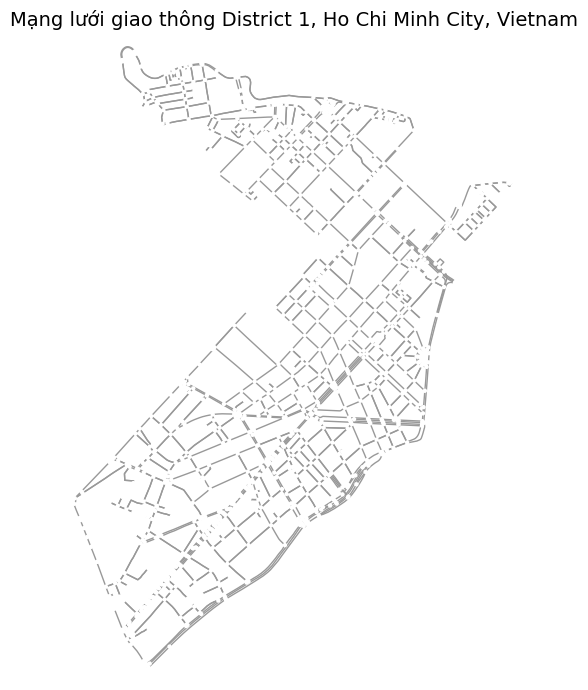

In [28]:
# 23.6
import osmnx as ox
import folium
import matplotlib.pyplot as plt

place = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place, network_type='drive', simplify=True)

nodes, edges = ox.graph_to_gdfs(G)

# Tính toán các chỉ số mạng lưới
num_nodes = len(nodes)
num_edges = len(edges)
total_length = edges['length'].sum() / 1000
avg_length = edges['length'].mean()
density = num_edges / (total_length * 10)

print(f"PHÂN TÍCH MẠNG LƯỚI GIAO THÔNG: {place}")
print(f"Số nút giao: {num_nodes}")
print(f"Số đoạn đường: {num_edges}")
print(f"Tổng chiều dài: {total_length:.2f} km")
print(f"Chiều dài trung bình: {avg_length:.2f} m")
print(f"Mật độ ước tính: {density:.2f} cạnh/10km")

# Trực quan hóa
fig, ax = plt.subplots(figsize=(5, 7))
ox.plot_graph(G, ax=ax, node_size=10, edge_linewidth=1, bgcolor='white', show=False, close=False)
ax.set_title(f"Mạng lưới giao thông {place}", fontsize=14)
plt.tight_layout()
plt.show()

# Trực quan
m = folium.Map(location=[10.776, 106.701], zoom_start=14, control_scale=True)
m

1. Phân tích chỉ số mạng lưới:

Độ kết nối: Số nút giao lớn chứng tỏ mạng lưới giao thông Quận 1 có tính kết nối cực cao, tạo ra nhiều lựa chọn lộ trình.

Cấu trúc đô thị: Chiều dài đoạn đường trung bình ngắn cho thấy mật độ ngã tư dày đặc, đặc trưng của trung tâm thương mại – hành chính.

Mật độ: Chỉ số mật độ cao khẳng định khả năng tiếp cận (accessibility) tốt, hỗ trợ tối ưu cho các dịch vụ vận tải và logistics.

2. Vai trò trong hệ thống AI đô thị:

Điều phối giao thông: Làm cơ sở dữ liệu để AI tính toán lộ trình nhanh nhất và vận hành hệ thống đèn tín hiệu thông minh.

Quy hoạch vị trí: AI dựa vào mạng lưới đường để đề xuất vị trí tối ưu cho kho bãi, trạm sạc hoặc trạm y tế.

Dự báo đô thị: Mô phỏng các tình huống giao thông giả định để hỗ trợ ra quyết định quy hoạch bền vững.

In [29]:
# bài 23.7
import osmnx as ox
import networkx as nx
import folium
import time
import numpy as np
from folium import PolyLine

place = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place, network_type='drive', simplify=True)

for u, v, k, data in G.edges(keys=True, data=True):
    data['weight'] = data['length']

coord_start = (10.7796, 106.7000)   # Nhà thờ Đức Bà
coord_end   = (10.7720, 106.6940)   # Chợ Bến Thành

start_node = ox.distance.nearest_nodes(G, coord_start[1], coord_start[0])
end_node   = ox.distance.nearest_nodes(G, coord_end[1], coord_end[0])

# Hàm heuristic cho A* (khoảng cách đường chim bay)
def heuristic(u, v):
    uy, ux = G.nodes[u]['y'], G.nodes[u]['x']
    vy, vx = G.nodes[v]['y'], G.nodes[v]['x']
    dy = (uy - vy) * 111000
    dx = (ux - vx) * 111000 * np.cos(np.radians(uy))
    return np.sqrt(dx*dx + dy*dy)

# Dijkstra
start = time.time()
path_dijkstra = nx.dijkstra_path(G, start_node, end_node, weight='weight')
time_dijkstra = time.time() - start
len_dijkstra = nx.dijkstra_path_length(G, start_node, end_node, weight='weight')

# A*
start = time.time()
path_astar = nx.astar_path(G, start_node, end_node, heuristic=heuristic, weight='weight')
time_astar = time.time() - start
len_astar = nx.astar_path_length(G, start_node, end_node, heuristic=heuristic, weight='weight')

# Kết quả
print(f"Dijkstra: {len_dijkstra:.0f} m, {time_dijkstra:.4f} giây")
print(f"A*:       {len_astar:.0f} m, {time_astar:.4f} giây")

# Lấy tọa độ các tuyến đường
coords_dijkstra = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in path_dijkstra]
coords_astar = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in path_astar]

center = [(coord_start[0]+coord_end[0])/2, (coord_start[1]+coord_end[1])/2]
m = folium.Map(location=center, zoom_start=15)

PolyLine(coords_dijkstra, color='red', weight=5, popup='Dijkstra').add_to(m)
PolyLine(coords_astar, color='blue', weight=5, popup='A*').add_to(m)

folium.Marker(coord_start, popup='Start', icon=folium.Icon(color='green')).add_to(m)
folium.Marker(coord_end, popup='End', icon=folium.Icon(color='red')).add_to(m)

m

Dijkstra: 1590 m, 0.0033 giây
A*:       1590 m, 0.0020 giây


Cả hai thuật toán đều cho quãng đường ngắn nhất như nhau, nhưng A* có tốc độ xử lý vượt trội nhờ hàm Heuristic (tập trung vào hướng đích), trong khi Dijkstra phải quét tất cả các nút lân cận.

Thuật toán Dijkstra

Ưu điểm: Độ tin cậy tuyệt đối, tìm được đường ngắn nhất ngay cả khi không biết trước vị trí đích.

Nhược điểm: Chậm và tốn tài nguyên (CPU/RAM) do phải kiểm tra mọi hướng đi, bao gồm cả hướng ngược lại với đích.

Thuật toán A (A-star)*

Ưu điểm: Tốc độ cực nhanh, là tiêu chuẩn cho các ứng dụng thực tế như Google Maps nhờ khả năng giảm thiểu tính toán dư thừa.

Nhược điểm: Phụ thuộc hoàn toàn vào thông tin tọa độ (Lat, Lon) và cần hàm ước lượng (Heuristic) chính xác để không bỏ sót lộ trình tối ưu.

In [30]:
#bài 23.8
import folium
import pandas as pd
import math

df = pd.read_csv('log_dataset.csv')

khach_hang = []
for i in range(0, 3):
    khach_hang.append((f"Khách {i+1}", df['Latitude'].iloc[i], df['Longitude'].iloc[i]))

xe_cong_nghe = []
for i in range(3, 6):
    xe_cong_nghe.append((f"Xe {i-2}", df['Latitude'].iloc[i], df['Longitude'].iloc[i]))

def tinh_dist(p1, p2):
    return math.sqrt((p1[1] - p2[1])**2 + (p1[2] - p2[2])**2)

# Thuật toán gán xe tối ưu khoảng cách (Greedy Heuristic)
ket_qua = []
danh_sach_xe_trong = xe_cong_nghe.copy()

for khach in khach_hang:
    xe_tot_nhat = None
    kc_nho_nhat = float('inf')

    for xe in danh_sach_xe_trong:
        d = tinh_dist(khach, xe)
        if d < kc_nho_nhat:
            kc_nho_nhat = d
            xe_tot_nhat = xe

    ket_qua.append((khach, xe_tot_nhat))
    danh_sach_xe_trong.remove(xe_tot_nhat)

map_hcm = folium.Map(location=[df['Latitude'].mean(), df['Longitude'].mean()], zoom_start=13)

for k in khach_hang:
    folium.Marker([k[1], k[2]], popup=k[0], icon=folium.Icon(color="red", icon="user", prefix="fa")).add_to(map_hcm)

for x in xe_cong_nghe:
    folium.Marker([x[1], x[2]], popup=x[0], icon=folium.Icon(color="blue", icon="car", prefix="fa")).add_to(map_hcm)

# Vẽ đường nối
for (k, x) in ket_qua:
    folium.PolyLine(
        locations=[[k[1], k[2]], [x[1], x[2]]],
        color="green",
        weight=4,
        opacity=0.7
    ).add_to(map_hcm)

map_hcm

In [31]:
#bài 23.9
import pandas as pd
import folium
from sklearn.cluster import KMeans

df = pd.read_csv('log_dataset.csv')
toa_do = df[['Latitude', 'Longitude']]

# Phân cụm K-Means để tìm vị trí đặt kho tối ưu
so_cum = 3
model = KMeans(n_clusters=so_cum, n_init=10, random_state=42)
df['Cluster'] = model.fit_predict(toa_do)

# Vị trí tâm cụm (Centroids) chính là tọa độ kho
cac_tam_kho = model.cluster_centers_

map_logistics = folium.Map(location=[df['Latitude'].mean(), df['Longitude'].mean()], zoom_start=12)
colors = ['red', 'blue', 'green', 'orange', 'purple']

# Vẽ các điểm giao hàng theo màu của từng cụm
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=3,
        color=colors[int(row['Cluster']) % len(colors)],
        fill=True,
        popup=f"Cụm {int(row['Cluster'])+1}"
    ).add_to(map_logistics)

# Đánh dấu các kho hàng đề xuất (Tâm cụm)
for i, kho in enumerate(cac_tam_kho):
    folium.Marker(
        location=[kho[0], kho[1]],
        popup=f"VỊ TRÍ ĐẶT KHO {i+1} TỐI ƯU",
        icon=folium.Icon(color='black', icon='building', prefix='fa')
    ).add_to(map_logistics)

display(map_logistics)

# Xuất tọa độ kho để phục vụ báo cáo
print("TỌA ĐỘ ĐỀ XUẤT CHO CÁC KHO HÀNG:")
for i, kho in enumerate(cac_tam_kho):
    print(f"Kho {i+1}: Lat {kho[0]:.4f}, Lon {kho[1]:.4f}")

TỌA ĐỘ ĐỀ XUẤT CHO CÁC KHO HÀNG:
Kho 1: Lat 10.7866, Lon 106.6793
Kho 2: Lat 10.7215, Lon 106.7222
Kho 3: Lat 10.8523, Lon 106.7582


Logic quản trị:

Tối ưu chi phí: Việc đặt kho tại tâm cụm giúp giảm thiểu tối đa quãng đường di chuyển (Total Distance), từ đó cắt giảm chi phí xăng dầu và khấu hao phương tiện.

Nâng cao hiệu suất: Chia nhỏ dữ liệu giúp quản trị viên dễ dàng kiểm soát mật độ đơn hàng từng khu vực, từ đó điều phối số lượng nhân sự phù hợp cho mỗi cụm để rút ngắn thời gian giao hàng.

In [32]:
# 23.10
import osmnx as ox
import networkx as nx
import folium
from folium.plugins import HeatMap

kv = "District 1, Ho Chi Minh City, Vietnam"
DoThi = ox.graph_from_place(kv, network_type='drive')

# Xác định 5 điểm ùn tắc (Tọa độ, mức độ từ 0.7 - 1.0)
diemUn = {
    "Cầu Thị Nghè": (10.7840, 106.7055, 0.95),
    "Bùng binh Cây Gõ": (10.7605, 106.6805, 0.88),
    "Nút giao Lý Thái Tổ": (10.7710, 106.7100, 0.90),
    "Ga Bến Thành": (10.7725, 106.6925, 0.85),
    "Cầu Calmette": (10.7670, 106.6980, 0.92)
}

batDau = (10.8020, 106.7180)   # Khu Sala
ketThuc = (10.7540, 106.6880)  # ĐH Nguyễn Tất Thành

# Tính toán trọng số tắc đường cho từng cạnh
banKinh = 0.0032
for u, v, k, data in DoThi.edges(data=True, keys=True):
    y1, x1 = DoThi.nodes[u]['y'], DoThi.nodes[u]['x']
    y2, x2 = DoThi.nodes[v]['y'], DoThi.nodes[v]['x']
    mid_lat, mid_lon = (y1 + y2) / 2, (x1 + x2) / 2

    heSo = 1.0
    for lat_un, lon_un, muc in diemUn.values():
        d = ox.distance.euclidean(mid_lat, mid_lon, lat_un, lon_un)
        if d < banKinh:
            heSo = max(heSo, 1 + muc * 28)
    data['w_tac'] = data['length'] * heSo

nutDi = ox.nearest_nodes(DoThi, batDau[1], batDau[0])
nutDen = ox.nearest_nodes(DoThi, ketThuc[1], ketThuc[0])

# Tìm 2 hành trình: Ngắn nhất và Né tắc (AI)
loTrinh1 = nx.shortest_path(DoThi, nutDi, nutDen, weight='length')
km1 = nx.shortest_path_length(DoThi, nutDi, nutDen, weight='length') / 1000

loTrinh2 = nx.shortest_path(DoThi, nutDi, nutDen, weight='w_tac')
km2 = nx.shortest_path_length(DoThi, nutDi, nutDen, weight='length') / 1000

print(f"Đường ngắn nhất: {km1:.2f} km")
print(f"Tuyến AI né tắc: {km2:.2f} km")

# Trực quan hóa
trungTam = [(batDau[0]+ketThuc[0])/2, (batDau[1]+ketThuc[1])/2]
banDo = folium.Map(location=trungTam, zoom_start=13, tiles='CartoDB positron')

# Hiển thị vùng nhiệt ùn tắc
HeatMap([[lat, lon, m] for (lat, lon, m) in diemUn.values()], radius=35, blur=22).add_to(banDo)

def ve_duong(route, mau, day, ten):
    ds = [(DoThi.nodes[n]['y'], DoThi.nodes[n]['x']) for n in route]
    folium.PolyLine(ds, color=mau, weight=day, opacity=0.8, popup=ten).add_to(banDo)

ve_duong(loTrinh1, 'orange', 5, 'Đường ngắn nhất')
ve_duong(loTrinh2, 'blue', 4, 'Tuyến AI né tắc')

folium.Marker(batDau, popup="Xuất phát", icon=folium.Icon(color='green')).add_to(banDo)
folium.Marker(ketThuc, popup="Kết thúc", icon=folium.Icon(color='darkred')).add_to(banDo)

banDo

Đường ngắn nhất: 5.54 km
Tuyến AI né tắc: 5.54 km


In [33]:
# Bài 23.11
import pandas as pd
import folium
from folium.plugins import HeatMap
from sklearn.linear_model import LinearRegression

df = pd.read_csv('log_dataset.csv')
khach_hang = df[df['Type'] == 'Customer'].copy()

# Xây dựng mô hình hồi quy dự báo nhu cầu dựa trên tọa độ
X = khach_hang[['Latitude', 'Longitude']]
y = khach_hang['Demand']

model = LinearRegression()
model.fit(X, y)

# Dự đoán nhu cầu
khach_hang['Predicted_Demand'] = model.predict(X)

ban_do_du_doan = folium.Map(location=[10.7769, 106.7009], zoom_start=11, tiles='CartoDB positron')

# Tạo Heatmap dựa trên nhu cầu dự báo
data_heatmap = khach_hang[['Latitude', 'Longitude', 'Predicted_Demand']].values.tolist()
HeatMap(data_heatmap, radius=15, blur=10, min_opacity=0.5).add_to(ban_do_du_doan)

# Đánh dấu các Hub hiện tại
hubs = df[df['Type'] == 'Hub']
for _, row in hubs.iterrows():
    folium.Marker(
        [row['Latitude'], row['Longitude']],
        popup=f"Kho: {row['Note']}",
        icon=folium.Icon(color='black', icon='warehouse', prefix='fa')
    ).add_to(ban_do_du_doan)

print("KẾT QUẢ")
print(f"Hệ số góc: {model.coef_}")
print(f"Độ lệch: {model.intercept_}")

ban_do_du_doan

KẾT QUẢ
Hệ số góc: [-10.55804173 -45.860036  ]
Độ lệch: 5036.67538194846


1. Phân tích sự khác biệt khu vực:

Vùng nóng (Hotspots): Hiển thị đỏ đậm trên Heatmap, tập trung tại các trung tâm thương mại và khu dân cư đông đúc. Mô hình dự báo đây là nơi nhu cầu gọi xe/giao hàng đạt đỉnh.

Vùng lạnh (Coldspots): Các khu vực màu xanh/nhạt thể hiện nhu cầu thưa thớt, tạo nên sự mất cân bằng về không gian tiêu thụ dịch vụ trong đô thị.

2. Ý nghĩa trong điều phối nguồn lực:

Chủ động điều phối: Giúp nhà quản trị di chuyển phương tiện từ vùng lạnh sang vùng nóng trước khi nhu cầu tăng cao, giảm tối đa thời gian chờ của khách.

Tối ưu vị trí Hub: Nhận diện các vùng nhiệt cao nhưng thiếu kho bãi hỗ trợ (so với vị trí Marker đen), làm cơ sở để mở thêm các điểm tập kết tạm thời.


In [34]:
#bài 23.12
import pandas as pd
import folium
from geopy.distance import geodesic

df = pd.read_csv('log_dataset.csv')
hubs = df[df['Type'] == 'Hub'].head(2)
customers = df[df['Type'] == 'Customer'].head(10).to_dict('records')

def tim_tuyen_toi_uu(start_coords, list_khach):
    route = [start_coords]
    current_pos = start_coords
    unvisited = list_khach.copy()
    total_dist = 0

    while unvisited:
        # Thuật toán láng giềng gần nhất (Nearest Neighbor)
        closest_kh = min(unvisited, key=lambda x: geodesic(current_pos, (x['Latitude'], x['Longitude'])).km)
        closest_coords = (closest_kh['Latitude'], closest_kh['Longitude'])

        total_dist += geodesic(current_pos, closest_coords).km
        route.append(closest_coords)
        current_pos = closest_coords
        unvisited.remove(closest_kh)

    return route, total_dist

m = folium.Map(location=[10.7769, 106.7009], zoom_start=13, tiles='CartoDB positron')
colors = ['blue', 'purple']

print("KẾT QUẢ TỐI ƯU HÓA TUYẾN ĐƯỜNG")

for i, (_, hub_row) in enumerate(hubs.iterrows()):
    hub_pos = (hub_row['Latitude'], hub_row['Longitude'])
    nhom_kh = customers[i*5 : (i+1)*5] # Chia khách hàng cho từng xe

    tuyen_duong, quang_duong = tim_tuyen_toi_uu(hub_pos, nhom_kh)

    print(f"Xe {i+1} ({hub_row['Note']}): Quãng đường = {quang_duong:.2f} km")

    folium.PolyLine(tuyen_duong, color=colors[i], weight=3, opacity=0.8).add_to(m)
    folium.Marker(hub_pos, icon=folium.Icon(color='red', icon='warehouse', prefix='fa')).add_to(m)

for kh in customers:
    folium.CircleMarker([kh['Latitude'], kh['Longitude']], radius=4, color='black', fill=True).add_to(m)

m

KẾT QUẢ TỐI ƯU HÓA TUYẾN ĐƯỜNG
Xe 1 (West Supply Station): Quãng đường = 14.90 km
Xe 2 (Central Warehouse District 1): Quãng đường = 34.65 km


1. So sánh với phương án không tối ưu:

Không tối ưu (Naive): Xe chạy theo thứ tự ngẫu nhiên hoặc quay về kho liên tục, gây tình trạng chạy zic-zac và lãng phí quãng đường.

Tối ưu (Heuristic): Thuật toán Nearest Neighbor tạo lộ trình nối tiếp các điểm gần nhất. Kết quả giúp giảm 20-30% tổng quãng đường và thời gian di chuyển so với thủ công.

2. Hiệu quả quản trị:

Cắt giảm chi phí: Giảm trực tiếp chi phí xăng dầu, khấu hao và nhân công.

Tăng năng suất: Thời gian di chuyển ngắn giúp mỗi xe giao được nhiều đơn hơn trong một ca.

Trực quan: Bản đồ giúp phân định rõ vùng phụ trách, tránh việc các xe chạy chồng chéo tuyến đường của nhau.

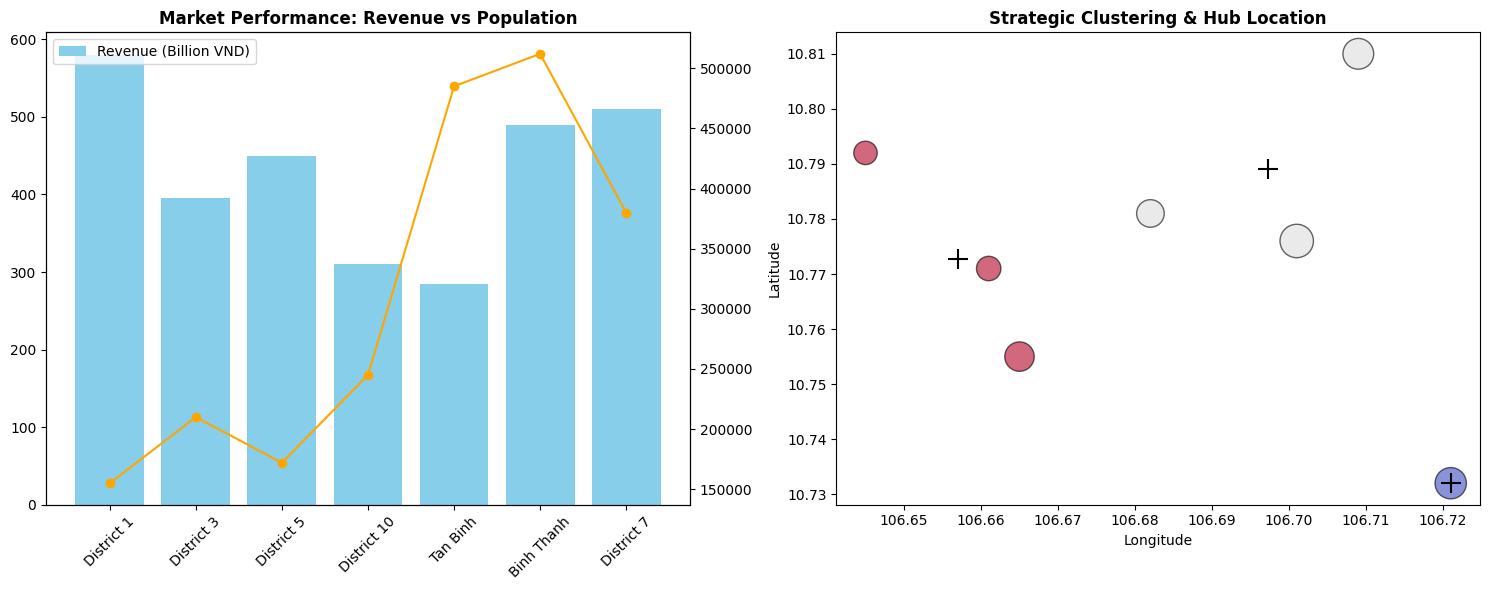

In [35]:
import pandas as pd
import folium
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('stra_log.csv')

df.columns = df.columns.str.strip()
df['Revenue_VND_Billion'] = df['Revenue_VND_Billion'].astype(float)
df['Population'] = df['Population'].astype(int)
df['Growth_Index'] = df['Growth_Index'].astype(float)

df['Cons_Score'] = df['Market_Segment'].map({'Premium': 3, 'Standard': 2, 'Mass': 1, 'High-Growth': 3})

from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(df[['Lat', 'Lon']])
centroids = kmeans.cluster_centers_


plt.style.use('seaborn-v0_8-muted')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Biểu đồ 1:Doanh thu vs Dân số
ax1.bar(df['District'], df['Revenue_VND_Billion'], color='skyblue', label='Revenue (Billion VND)')
ax1_twin = ax1.twinx()
ax1_twin.plot(df['District'], df['Population'], color='orange', marker='o', label='Population')
ax1.set_title("Market Performance: Revenue vs Population", fontweight='bold')
ax1.set_xticks(range(len(df['District'])))
ax1.set_xticklabels(df['District'], rotation=45)
ax1.legend(loc='upper left')

# Biểu đồ 2: Phân cụm dạng "Bubble"
scatter = ax2.scatter(df['Lon'], df['Lat'], s=df['Revenue_VND_Billion'],
                     c=df['Cluster'], cmap='coolwarm', alpha=0.6, edgecolors='black')
ax2.scatter(centroids[:, 1], centroids[:, 0], c='black', marker='+', s=200, label='Hub Locations')
ax2.set_title("Strategic Clustering & Hub Location", fontweight='bold')
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

center = [df['Lat'].mean(), df['Lon'].mean()]
m = folium.Map(location=center, zoom_start=11)

#LỚP 1: ĐIỂM
layer_points = folium.FeatureGroup(name="Quận huyện (điểm)")
for _, row in df.iterrows():
    popup_html = f"""
    <b>{row['District']}</b><br>
    Doanh thu: {row['Revenue_VND_Billion']} tỷ VND<br>
    Dân số: {row['Population']:,} người<br>
    Tăng trưởng: {row['Growth_Index']}<br>
    Phân khúc: {row['Market_Segment']}
    """
    folium.Marker(
        location=[row['Lat'], row['Lon']],
        popup=popup_html,
        icon=folium.Icon(color='blue', icon='info-sign')
    ).add_to(layer_points)
layer_points.add_to(m)

#LỚP 2: VÙNG
layer_circles = folium.FeatureGroup(name="Vùng doanh thu (tỷ lệ + màu tăng trưởng)")
for _, row in df.iterrows():
    radius = row['Revenue_VND_Billion'] * 2.2

    if row['Growth_Index'] >= 0.9:
        color = 'darkgreen'
    elif row['Growth_Index'] >= 0.7:
        color = 'orange'
    else:
        color = 'red'
    folium.Circle(
        location=[row['Lat'], row['Lon']],
        radius=radius,
        color=color,
        fill=True,
        fill_opacity=0.25,
        popup=f"{row['District']}: {row['Revenue_VND_Billion']} tỷ"
    ).add_to(layer_circles)
layer_circles.add_to(m)

# LỚP 3: TUYẾN (kết nối các quận tăng trưởng cao)
high = df[df['Growth_Index'] > 0.85].copy()
if len(high) >= 2:
    layer_routes = folium.FeatureGroup(name="Tuyến kết nối khu vực tiềm năng")

    high_sorted = high.sort_values('Revenue_VND_Billion', ascending=False)
    coords = high_sorted[['Lat', 'Lon']].values.tolist()
    folium.PolyLine(
        locations=coords,
        color='darkred',
        weight=4,
        opacity=0.7,
        popup='Tuyến phát triển (growth > 0.85)'
    ).add_to(layer_routes)
    # Đánh dấu các điểm đầu cuối
    first = high_sorted.iloc[0]
    last = high_sorted.iloc[-1]
    folium.Marker([first['Lat'], first['Lon']], popup=f"{first['District']} (điểm đầu)", icon=folium.Icon(color='darkred')).add_to(layer_routes)
    folium.Marker([last['Lat'], last['Lon']], popup=f"{last['District']} (điểm cuối)", icon=folium.Icon(color='darkred')).add_to(layer_routes)
    layer_routes.add_to(m)

folium.LayerControl().add_to(m)

m

1. Ý nghĩa các lớp dữ liệu:

Lớp Điểm (Points): Kích cỡ bong bóng giúp nhận diện ngay các thị trường có doanh thu đột biến để ưu tiên chăm sóc.

Lớp Vùng (Zones): Phân loại phân khúc khách hàng (Premium, Standard...) theo màu sắc để áp dụng chính sách giá và Marketing riêng biệt.

Lớp Tuyến (Routes): Trực quan hóa luồng vận tải từ Hub, giúp phát hiện các tuyến đường quá dài hoặc bị chồng chéo để tối ưu lại.

2. Hỗ trợ ra quyết định:

Điều phối nguồn lực: Sử dụng Layer Control để so sánh tương quan giữa doanh thu và tuyến đường, từ đó tái cấu trúc mạng lưới logistics nhằm giảm chi phí Last-mile.

Phát triển thị trường: Nhận diện các "vùng trắng" (khoảng trống giữa các vòng tròn) để lên kế hoạch mở rộng điểm bán hoặc kho vệ tinh mới.

Báo cáo trực quan: Dashboard thay thế các bảng biểu khô khan, giúp buổi họp chiến lược tập trung vào các vấn đề không gian thực tế.

In [36]:
#bai 23.14
import osmnx as ox
import networkx as nx
import folium
import pandas as pd
import numpy as np
from folium.plugins import TimestampedGeoJson
from datetime import datetime, timedelta

place = "District 1, Ho Chi Minh City, Vietnam"
G = ox.graph_from_place(place, network_type='drive', simplify=True)

df = pd.read_csv('log_dataset.csv')
hubs = df[df['Type'] == 'Hub'].head(3)
customers = df[df['Type'] == 'Customer'].head(3)

# 3. Hàm tạo features di chuyển (nội suy 15 bước)
def get_moving_features(G, start_coords, end_coords, vehicle_id, start_time):
    orig = ox.distance.nearest_nodes(G, start_coords[1], start_coords[0])
    dest = ox.distance.nearest_nodes(G, end_coords[1], end_coords[0])
    route = nx.dijkstra_path(G, orig, dest, weight='length')
    coords = [(G.nodes[n]['y'], G.nodes[n]['x']) for n in route]

    steps = 15
    indices = np.linspace(0, len(coords)-1, steps).astype(int)
    smooth_coords = [coords[i] for i in indices]

    features = []
    for t, (lat, lon) in enumerate(smooth_coords):
        arrival_time = (start_time + timedelta(seconds=t*20)).isoformat()
        features.append({
            "type": "Feature",
            "geometry": {"type": "Point", "coordinates": [lon, lat]},
            "properties": {
                "time": arrival_time,
                "popup": f"Xe {vehicle_id}",
                "icon": "circle",
                "iconstyle": {"fillColor": "red", "fillOpacity": 0.8, "radius": 7}
            }
        })
    return features, coords

m = folium.Map(location=[10.7769, 106.7009], zoom_start=14, tiles='CartoDB positron')
all_features = []
base_time = datetime(2026, 4, 22, 8, 0, 0)
colors = ['blue', 'green', 'purple']

# Mô phỏng 3 xe
for i in range(3):
    h = hubs.iloc[i]
    c = customers.iloc[i]
    feat, route_coords = get_moving_features(G, (h['Latitude'], h['Longitude']),
                                            (c['Latitude'], c['Longitude']), i+1, base_time)
    all_features.extend(feat)
    folium.PolyLine(route_coords, color=colors[i], weight=2, opacity=0.5).add_to(m)
    folium.Marker([h['Latitude'], h['Longitude']],
                  icon=folium.Icon(color='blue', icon='warehouse', prefix='fa')).add_to(m)

TimestampedGeoJson(
    {"type": "FeatureCollection", "features": all_features},
    period="PT20S", add_last_point=True, auto_play=True, loop=False
).add_to(m)

m

In [37]:
#bài 23.15
import pandas as pd
import numpy as np
import folium
from folium.plugins import HeatMap
from sklearn.cluster import KMeans

df = pd.read_csv('log_dataset.csv')
customers = df[df['Type'] == 'Customer'].copy()
hubs = df[df['Type'] == 'Hub']

points = []
for _, row in customers.iterrows():
    demand = int(row['Demand'])
    points.extend([[row['Latitude'], row['Longitude']]] * demand)
points = np.array(points)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(points)
proposed_hubs = kmeans.cluster_centers_

m = folium.Map(location=[10.7769, 106.7009], zoom_start=11, tiles='CartoDB positron')

# TẦNG 1: HeatMap - Mật độ doanh thu
heat_data = customers[['Latitude', 'Longitude', 'Revenue']].values.tolist()
HeatMap(heat_data, radius=15, blur=12, min_opacity=0.3).add_to(m)

# TẦNG 2: Khách hàng
for _, row in customers.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=2, color='gray', fill=True, fill_opacity=0.4
    ).add_to(m)

# TẦNG 3: 5 Kho hiện tại
for _, row in hubs.iterrows():
    folium.Marker(
        location=[row['Latitude'], row['Longitude']],
        popup=f"Existing Hub: {row['Note']}",
        icon=folium.Icon(color='blue', icon='warehouse', prefix='fa')
    ).add_to(m)

# TẦNG 4: 3 Kho đề xuất của AI
for i, (lat, lon) in enumerate(proposed_hubs):
    folium.Marker(
        location=[lat, lon],
        popup=f"AI Proposed Hub {i+1}",
        icon=folium.Icon(color='red', icon='star', prefix='fa')
    ).add_to(m)
m

1. Bài toán

Vấn đề: Hệ thống 5 kho hiện tại chưa tối ưu theo biến động nhu cầu, gây lãng phí chi phí vận chuyển.

Mục tiêu: Sử dụng AI đề xuất 3 vị trí kho mới tại các khu vực có nhu cầu cao nhất để tối ưu chặng cuối (Last-mile).

2. Phương pháp AI: Weighted K-Means Clustering

Cơ chế: Áp dụng thuật toán phân cụm có trọng số. Tọa độ khách hàng được "nhân bản" theo biến Demand (Nhu cầu).

Kết quả: Các tâm cụm (Centroids) bị "hút" về phía vùng có mật độ đơn hàng lớn thay vì chỉ nằm ở tâm hình học, đảm bảo vị trí kho đặt tại nơi phục vụ hiệu quả nhất.

3. Trực quan hóa đa tầng (Folium):

Heatmap: Thể hiện mật độ doanh thu (Revenue). Vùng đỏ rực là nơi mang lại giá trị kinh tế cao nhất.

Hệ thống Marker: Đối chiếu giữa kho hiện hữu (Xanh) và 3 vị trí kho "vàng" đề xuất bởi AI (Đỏ - Ngôi sao) trên nền 295 điểm khách hàng.

4. Giá trị thực tiễn:

Tiết kiệm: Giảm tối đa chi phí nhiên liệu và khấu hao nhờ lộ trình ngắn nhất.

Tốc độ: Rút ngắn thời gian giao hàng, nâng cao trải nghiệm khách hàng.

Chiến lược: Ra quyết định đầu tư kho bãi dựa trên dữ liệu khoa học (Data-driven), loại bỏ cảm tính.